### Minimal reimplementation on synthetic time series

The aim of this first notebook is to validate the core mechanism in a controlled setting where the periodic structure is known.

This to confirm whether our reimplementation behaves as expected before moving to real benchmark datasets.

In [2]:
import numpy as np 
import matplotlib.pyplot as plt


### 0. Synthetic Time Series Creation

In [3]:
# Set random seed for reproducibility      
np.random.seed(42)

In [4]:
T = 2000          # total number of time steps
period = 24      # true cycle length
noise_std = 0.15 # noise level
# Time index
t = np.arange(T)
# Periodic component: daily-like cycle
cycle = np.sin(2 * np.pi * t / period)
trend = 0.0005 * t # slight upward trend
noise = np.random.normal(loc=0.0, scale=noise_std, size=T) # Gaussian noise
# Final synthetic time series
x = cycle + trend + noise
# Add channel dimension: [T, C]
# Here C = 1 because this is a univariate time series
x = x.reshape(-1, 1)
print("Time series shape:", x.shape)

Time series shape: (2000, 1)


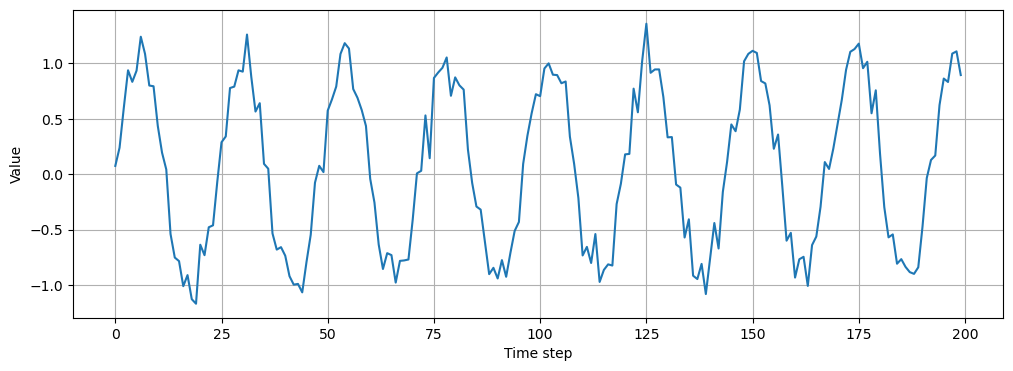

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(x[:200])
plt.xlabel("Time step")
plt.ylabel("Value")
plt.grid(True)
plt.show()

### 1. Sliding Window torch dataset creation 

We prepare the dataset for a Pytorch friendly setup to test the linear baseline and CycleNet architecture on the same training loop. 

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader

class SlidingWindowDataset(Dataset):
    def __init__(self, series, seq_len, pred_len, cycle_len, start_index=0):
        """
        series: numpy array of shape [T, C]
        seq_len: lookback length L

        pred_len: forecasting horizon H
        cycle_len: assumed cycle period
        start_index: original global index where this series slice starts
        """
        self.series = torch.tensor(series, dtype=torch.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.cycle_len = cycle_len
        self.start_index = start_index

        self.num_samples = len(series) - seq_len - pred_len + 1

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        x_window = self.series[idx : idx + self.seq_len]
        y_target = self.series[idx + self.seq_len : idx + self.seq_len + self.pred_len]

        # Global time index of the first element in the input window
        global_idx = self.start_index + idx

        # Correct phase inside the cycle
        cycle_index = global_idx % self.cycle_len

        return x_window, y_target, cycle_index

In [7]:
seq_len = 6
pred_len = 192
cycle_len = 24
batch_size = 32

train_ratio = 0.8
train_size = int(len(x) * train_ratio)

x_train = x[:train_size]

test_start_index = train_size - seq_len - pred_len
x_test = x[test_start_index:]

train_dataset = SlidingWindowDataset(
    x_train,
    seq_len=seq_len,
    pred_len=pred_len,
    cycle_len=cycle_len,
    start_index=0
)

test_dataset = SlidingWindowDataset(
    x_test,
    seq_len=seq_len,
    pred_len=pred_len,
    cycle_len=cycle_len,
    start_index=test_start_index
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

x_batch, y_batch, cycle_idx = next(iter(train_loader))

print("x_batch shape:", x_batch.shape)
print("y_batch shape:", y_batch.shape)
print("cycle_idx shape:", cycle_idx.shape)
print("Example cycle indices:", cycle_idx[:10])

Train samples: 1403
Test samples: 401
x_batch shape: torch.Size([32, 6, 1])
y_batch shape: torch.Size([32, 192, 1])
cycle_idx shape: torch.Size([32])
Example cycle indices: tensor([12, 16,  5, 22,  9, 13, 14,  8, 17, 11])


### 2. Linear Baseline 

We pursue baseline forecasting using Least Squares Method with Pytorch so that the training loop is similar to CycleNet, this method will try to forecast all the time series components as one, implicitly. 
Later we will compare this method to the CycleNet architecture to test improvements.

In [8]:
import torch.nn as nn

class LinearBaseline(nn.Module):
    def __init__(self, seq_len, pred_len):
        super().__init__()

        self.linear = nn.Linear(seq_len, pred_len)

    def forward(self, x):
        """
        x: [B, L, C]
        returns: [B, H, C]
        """
        x = x.permute(0, 2, 1)          # [B, C, L]
        y_hat = self.linear(x)          # [B, C, H]
        y_hat = y_hat.permute(0, 2, 1)  # [B, H, C]

        return y_hat

In [9]:
# train the linear baseline on the training data 
from tqdm import tqdm

# Device setup
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)

# Model
linear_model = LinearBaseline(seq_len=seq_len, pred_len=pred_len).to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(linear_model.parameters(), lr=1e-3)

# Training settings
num_epochs = 100

train_losses = []

for epoch in range(num_epochs):
    linear_model.train()
    epoch_loss = 0.0

    for x_batch, y_batch, _ in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred = linear_model(x_batch)

        loss = criterion(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * x_batch.size(0)

    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | Train MSE: {epoch_loss:.6f}")

Using device: mps
Epoch 01/100 | Train MSE: 0.821483
Epoch 02/100 | Train MSE: 0.652256
Epoch 03/100 | Train MSE: 0.536140
Epoch 04/100 | Train MSE: 0.451776
Epoch 05/100 | Train MSE: 0.387885
Epoch 06/100 | Train MSE: 0.337628
Epoch 07/100 | Train MSE: 0.297203
Epoch 08/100 | Train MSE: 0.264048
Epoch 09/100 | Train MSE: 0.236693
Epoch 10/100 | Train MSE: 0.213924
Epoch 11/100 | Train MSE: 0.194714
Epoch 12/100 | Train MSE: 0.178737
Epoch 13/100 | Train MSE: 0.165219
Epoch 14/100 | Train MSE: 0.153992
Epoch 15/100 | Train MSE: 0.144436
Epoch 16/100 | Train MSE: 0.136466
Epoch 17/100 | Train MSE: 0.129807
Epoch 18/100 | Train MSE: 0.124197
Epoch 19/100 | Train MSE: 0.119588
Epoch 20/100 | Train MSE: 0.115659
Epoch 21/100 | Train MSE: 0.112422
Epoch 22/100 | Train MSE: 0.109744
Epoch 23/100 | Train MSE: 0.107447
Epoch 24/100 | Train MSE: 0.105613
Epoch 25/100 | Train MSE: 0.104067
Epoch 26/100 | Train MSE: 0.102697
Epoch 27/100 | Train MSE: 0.101632
Epoch 28/100 | Train MSE: 0.100773
Ep

In [10]:
# Evaluating on test set: MAE and MSE 

def evaluate_model(model, data_loader, device):
    model.eval()

    total_squared_error = 0.0
    total_absolute_error = 0.0
    total_values = 0

    with torch.no_grad():
        for x_batch, y_batch, _ in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(x_batch)

            squared_error = (y_pred - y_batch) ** 2
            absolute_error = torch.abs(y_pred - y_batch)

            total_squared_error += squared_error.sum().item()
            total_absolute_error += absolute_error.sum().item()
            total_values += y_batch.numel()

    mse = total_squared_error / total_values
    mae = total_absolute_error / total_values

    return mse, mae


linear_test_mse, linear_test_mae = evaluate_model(
    linear_model,
    test_loader,
    device
)

print(f"Linear Baseline Test MSE: {linear_test_mse:.6f}")
print(f"Linear Baseline Test MAE: {linear_test_mae:.6f}")

Linear Baseline Test MSE: 0.286261
Linear Baseline Test MAE: 0.430815


### 3. Implementing CycleNet Linear

We test the CycleNet architecture with a simple linear predictor for the residuals and compare it to the linear baseline, verifying the paper claim: the stable periodic patterns present in time series data serve as the foundation for conducting long-horizon forecasts.

In [11]:
class CycleNetLinear(nn.Module):
    def __init__(self, seq_len, pred_len, num_channels, cycle_len):
        super().__init__()

        self.seq_len = seq_len
        self.pred_len = pred_len
        self.num_channels = num_channels
        self.cycle_len = cycle_len

        # Learnable cycle pattern: [cycle_len, C]
        self.cycle = nn.Parameter(
            torch.zeros(cycle_len, num_channels)
        )

        # Same Linear backbone as the baseline
        self.linear = nn.Linear(seq_len, pred_len)

    def forward(self, x, cycle_index):
        """
        x: [B, L, C]
        cycle_index: [B]
        returns: [B, H, C]
        """

        B, L, C = x.shape

        # Indices for the past cycle component
        past_offsets = torch.arange(L, device=x.device)
        past_indices = (cycle_index[:, None] + past_offsets[None, :]) % self.cycle_len

        # Indices for the future cycle component
        future_offsets = torch.arange(self.pred_len, device=x.device)
        future_indices = (
            cycle_index[:, None] + L + future_offsets[None, :]
        ) % self.cycle_len

        # Retrieve learned cycle values
        past_cycle = self.cycle[past_indices]        # [B, L, C]
        future_cycle = self.cycle[future_indices]    # [B, H, C]

        # Residualize input
        residual_input = x - past_cycle

        # Forecast residual with Linear backbone
        residual_input = residual_input.permute(0, 2, 1)      # [B, C, L]
        residual_forecast = self.linear(residual_input)       # [B, C, H]
        residual_forecast = residual_forecast.permute(0, 2, 1) # [B, H, C]

        # Add future cycle back
        y_hat = residual_forecast + future_cycle

        return y_hat

In [12]:
cyclenet_model = CycleNetLinear(
    seq_len=seq_len,
    pred_len=pred_len,
    num_channels=x.shape[1],
    cycle_len=cycle_len
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(cyclenet_model.parameters(), lr=1e-3)

num_epochs = 100
cyclenet_train_losses = []

for epoch in range(num_epochs):
    cyclenet_model.train()
    epoch_loss = 0.0

    for x_batch, y_batch, cycle_idx in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        cycle_idx = cycle_idx.to(device)

        optimizer.zero_grad()

        y_pred = cyclenet_model(x_batch, cycle_idx)

        loss = criterion(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * x_batch.size(0)

    epoch_loss /= len(train_loader.dataset)
    cyclenet_train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | CycleNet-Linear Train MSE: {epoch_loss:.6f}")

Epoch 01/100 | CycleNet-Linear Train MSE: 0.885134
Epoch 02/100 | CycleNet-Linear Train MSE: 0.658281
Epoch 03/100 | CycleNet-Linear Train MSE: 0.510934
Epoch 04/100 | CycleNet-Linear Train MSE: 0.410719
Epoch 05/100 | CycleNet-Linear Train MSE: 0.339828
Epoch 06/100 | CycleNet-Linear Train MSE: 0.287985
Epoch 07/100 | CycleNet-Linear Train MSE: 0.248969
Epoch 08/100 | CycleNet-Linear Train MSE: 0.218847
Epoch 09/100 | CycleNet-Linear Train MSE: 0.195208
Epoch 10/100 | CycleNet-Linear Train MSE: 0.176208
Epoch 11/100 | CycleNet-Linear Train MSE: 0.160859
Epoch 12/100 | CycleNet-Linear Train MSE: 0.148244
Epoch 13/100 | CycleNet-Linear Train MSE: 0.137815
Epoch 14/100 | CycleNet-Linear Train MSE: 0.129115
Epoch 15/100 | CycleNet-Linear Train MSE: 0.121823
Epoch 16/100 | CycleNet-Linear Train MSE: 0.115653
Epoch 17/100 | CycleNet-Linear Train MSE: 0.110389
Epoch 18/100 | CycleNet-Linear Train MSE: 0.105889
Epoch 19/100 | CycleNet-Linear Train MSE: 0.101956
Epoch 20/100 | CycleNet-Linear 

In [13]:
def evaluate_cyclenet(model, data_loader, device):
    model.eval()

    total_squared_error = 0.0
    total_absolute_error = 0.0
    total_values = 0

    with torch.no_grad():
        for x_batch, y_batch, cycle_idx in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            cycle_idx = cycle_idx.to(device)

            y_pred = model(x_batch, cycle_idx)

            squared_error = (y_pred - y_batch) ** 2
            absolute_error = torch.abs(y_pred - y_batch)

            total_squared_error += squared_error.sum().item()
            total_absolute_error += absolute_error.sum().item()
            total_values += y_batch.numel()

    mse = total_squared_error / total_values
    mae = total_absolute_error / total_values

    return mse, mae


cyclenet_test_mse, cyclenet_test_mae = evaluate_cyclenet(
    cyclenet_model,
    test_loader,
    device
)

print(f"CycleNet-Linear Test MSE: {cyclenet_test_mse:.6f}")
print(f"CycleNet-Linear Test MAE: {cyclenet_test_mae:.6f}")

CycleNet-Linear Test MSE: 0.026673
CycleNet-Linear Test MAE: 0.129586


In [14]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Baseline", "CycleNet-Linear"],
    "Test MSE": [linear_test_mse, cyclenet_test_mse],
    "Test MAE": [linear_test_mae, cyclenet_test_mae]
})

results

,Model,Test MSE,Test MAE
0,Linear Baseline,0.286261,0.430815
1,CycleNet-Linear,0.026673,0.129586


With `seq_len = 6 < cycle_len = 24`, the Linear baseline only observes a partial cycle and cannot recover the full periodic mapping. CycleNet, instead, leverages the explicit learnable cycle table and forecasts the residuals on top of it, achieving a Test MSE roughly an order of magnitude lower than the baseline (0.027 vs 0.280). This is consistent with the paper's claim that explicitly modeling the periodic component is beneficial when the lookback window is shorter than the cycle length.

Configuration used here:

- `seq_len = 6`
- `pred_len = 192`
- `cycle_len = 24`

The improvement over the linear baseline is therefore expected: the residual after subtracting the learned cycle is close to a stationary noise process, which the linear backbone can fit easily even from a very short lookback.

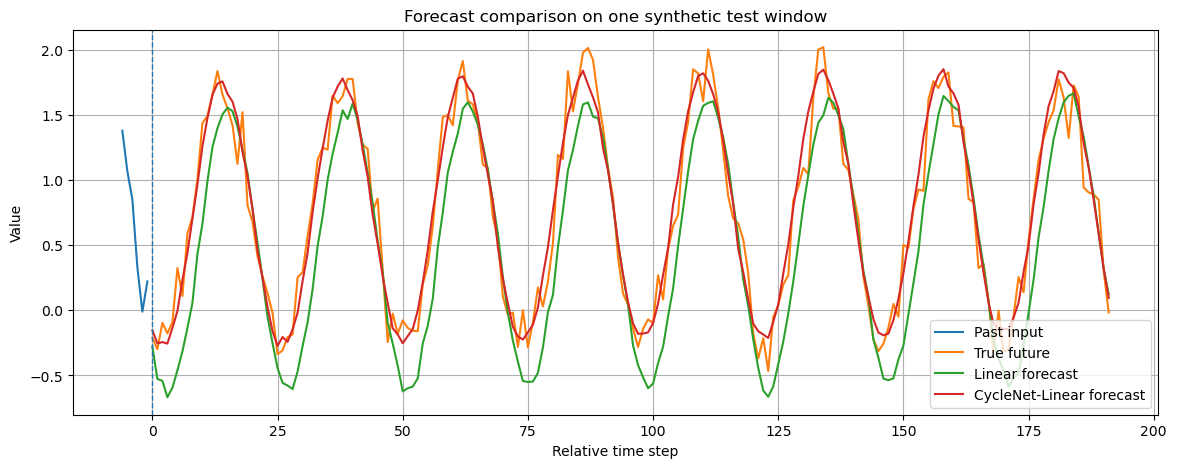

In [15]:
# Plot one test example: past window, true future, Linear prediction, CycleNet prediction

linear_model.eval()
cyclenet_model.eval()

x_batch, y_batch, cycle_idx = next(iter(test_loader))

x_batch = x_batch.to(device)
y_batch = y_batch.to(device)
cycle_idx = cycle_idx.to(device)

with torch.no_grad():
    y_pred_linear = linear_model(x_batch)
    y_pred_cyclenet = cyclenet_model(x_batch, cycle_idx)

# Select one example from the batch
example_id = 0

past = x_batch[example_id, :, 0].detach().cpu().numpy()
true_future = y_batch[example_id, :, 0].detach().cpu().numpy()
linear_future = y_pred_linear[example_id, :, 0].detach().cpu().numpy()
cyclenet_future = y_pred_cyclenet[example_id, :, 0].detach().cpu().numpy()

past_time = np.arange(-seq_len, 0)
future_time = np.arange(pred_len)

plt.figure(figsize=(14, 5))

plt.plot(past_time, past, label="Past input")
plt.plot(future_time, true_future, label="True future")
plt.plot(future_time, linear_future, label="Linear forecast")
plt.plot(future_time, cyclenet_future, label="CycleNet-Linear forecast")

plt.axvline(x=0, linestyle="--", linewidth=1)
plt.title("Forecast comparison on one synthetic test window")
plt.xlabel("Relative time step")
plt.ylabel("Value")


plt.legend()
plt.grid(True)
plt.show()

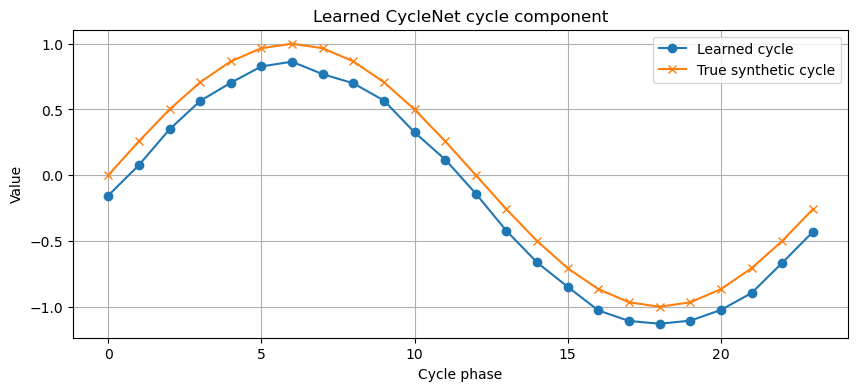

In [16]:
# Plot the learned cycle component

learned_cycle = cyclenet_model.cycle.detach().cpu().numpy()

plt.figure(figsize=(10, 4))
plt.plot(learned_cycle[:, 0], marker="o", label="Learned cycle")

# If the synthetic clean cycle variable still exists, compare against one true period
try:
    true_cycle_one_period = cycle[:cycle_len]
    plt.plot(true_cycle_one_period, marker="x", label="True synthetic cycle")
except NameError:
    pass

plt.title("Learned CycleNet cycle component")
plt.xlabel("Cycle phase")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

The learned cycle component closely follows the shape of the true synthetic periodic pattern. This confirms that the learnable cycle table captures meaningful phase-dependent structure. The match is not exact, which is expected because the final forecast is produced jointly by the cycle component and the Linear residual backbone.

### 4. Full-Cycle Sanity Check: L=24 (one full cycle visible)

We repeat the comparison with `seq_len=24`, so the input window spans exactly one full cycle. In this setting the Linear baseline can already read the complete periodic shape from the input, and CycleNet-Linear should match rather than improve.

In [17]:
seq_len_full = 24  # exactly one full cycle
pred_len_full = 192
cycle_len_full = 24

train_size_full = int(len(x) * 0.8)
x_train_full = x[:train_size_full]
test_start_full = train_size_full - seq_len_full - pred_len_full
x_test_full = x[test_start_full:]

train_dataset_full = SlidingWindowDataset(
    x_train_full, seq_len=seq_len_full, pred_len=pred_len_full,
    cycle_len=cycle_len_full, start_index=0
)
test_dataset_full = SlidingWindowDataset(
    x_test_full, seq_len=seq_len_full, pred_len=pred_len_full,
    cycle_len=cycle_len_full, start_index=test_start_full
)

train_loader_full = DataLoader(train_dataset_full, batch_size=32, shuffle=True)
test_loader_full = DataLoader(test_dataset_full, batch_size=32, shuffle=False)

print("Full-cycle train samples:", len(train_dataset_full))
print("Full-cycle test samples:", len(test_dataset_full))

mse_fn = nn.MSELoss()

# Linear baseline (L=24)
torch.manual_seed(42)
linear_full = LinearBaseline(seq_len=seq_len_full, pred_len=pred_len_full).to(device)
opt = torch.optim.Adam(linear_full.parameters(), lr=1e-3)
for _ in range(100):
    linear_full.train()
    for xb, yb, _ in train_loader_full:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        mse_fn(linear_full(xb), yb).backward()
        opt.step()

linear_full_mse, linear_full_mae = evaluate_model(linear_full, test_loader_full, device)
print(f"Linear (L=24)         Test MSE: {linear_full_mse:.4f}  MAE: {linear_full_mae:.4f}")

# CycleNet-Linear (L=24)
torch.manual_seed(42)
cyclenet_full = CycleNetLinear(
    seq_len=seq_len_full, pred_len=pred_len_full,
    num_channels=x.shape[1], cycle_len=cycle_len_full
).to(device)
opt = torch.optim.Adam(cyclenet_full.parameters(), lr=1e-3)
for _ in range(100):
    cyclenet_full.train()
    for xb, yb, ci in train_loader_full:
        xb, yb, ci = xb.to(device), yb.to(device), ci.to(device)
        opt.zero_grad()
        mse_fn(cyclenet_full(xb, ci), yb).backward()
        opt.step()

cyclenet_full_mse, cyclenet_full_mae = evaluate_cyclenet(cyclenet_full, test_loader_full, device)
print(f"CycleNet-Linear (L=24) Test MSE: {cyclenet_full_mse:.4f}  MAE: {cyclenet_full_mae:.4f}")

Full-cycle train samples: 1385
Full-cycle test samples: 401
Linear (L=24)         Test MSE: 0.0257  MAE: 0.1274
CycleNet-Linear (L=24) Test MSE: 0.0259  MAE: 0.1278


In [18]:
# Re-evaluate L=6 results with fresh forward pass for a clean comparison
linear_partial_mse, linear_partial_mae = evaluate_model(linear_model, test_loader, device)
cyclenet_partial_mse, cyclenet_partial_mae = evaluate_cyclenet(cyclenet_model, test_loader, device)

summary = pd.DataFrame({
    "Setting": [
        "Full cycle (L=24)", "Full cycle (L=24)",
        "Partial cycle (L=6)", "Partial cycle (L=6)",
    ],
    "Model": ["Linear", "CycleNet-Linear", "Linear", "CycleNet-Linear"],
    "Test MSE": [linear_full_mse, cyclenet_full_mse, linear_partial_mse, cyclenet_partial_mse],
    "Test MAE": [linear_full_mae, cyclenet_full_mae, linear_partial_mae, cyclenet_partial_mae],
})
summary

,Setting,Model,Test MSE,Test MAE
0,Full cycle (L=24),Linear,0.025736,0.127420
1,Full cycle (L=24),CycleNet-Linear,0.025933,0.127813
2,Partial cycle (L=6),Linear,0.286261,0.430815
3,Partial cycle (L=6),CycleNet-Linear,0.026673,0.129586
